# BTC 5-Minute Market Analysis

Up/down token prices and price diff from `price_log.jsonl`.


In [1]:
import json
import pandas as pd
from datetime import datetime

records = []
with open('price_log.jsonl') as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
df['time'] = pd.to_datetime(df['timestamp'], unit='s')
df['window_label'] = pd.to_datetime(df['window_start'], unit='s').dt.strftime('%H:%M')
print(f"Total rows: {len(df)}, Distinct 5m windows: {df['window_start'].nunique()}")
df.head()

Total rows: 43174, Distinct 5m windows: 22


,current_price,down_price,price_diff,remaining_seconds,start_price,timestamp,up_price,window_start,time,window_label
0,0.0,0.98,0.0,61,0.0,1775218739,0.02,1775218500,2026-04-03 12:18:59,12:15
1,0.0,0.97,0.0,61,0.0,1775218739,0.03,1775218500,2026-04-03 12:18:59,12:15
2,0.0,0.98,0.0,60,0.0,1775218740,0.02,1775218500,2026-04-03 12:19:00,12:15
3,0.0,0.98,0.0,60,0.0,1775218740,0.02,1775218500,2026-04-03 12:19:00,12:15
4,0.0,0.97,0.0,60,0.0,1775218740,0.03,1775218500,2026-04-03 12:19:00,12:15


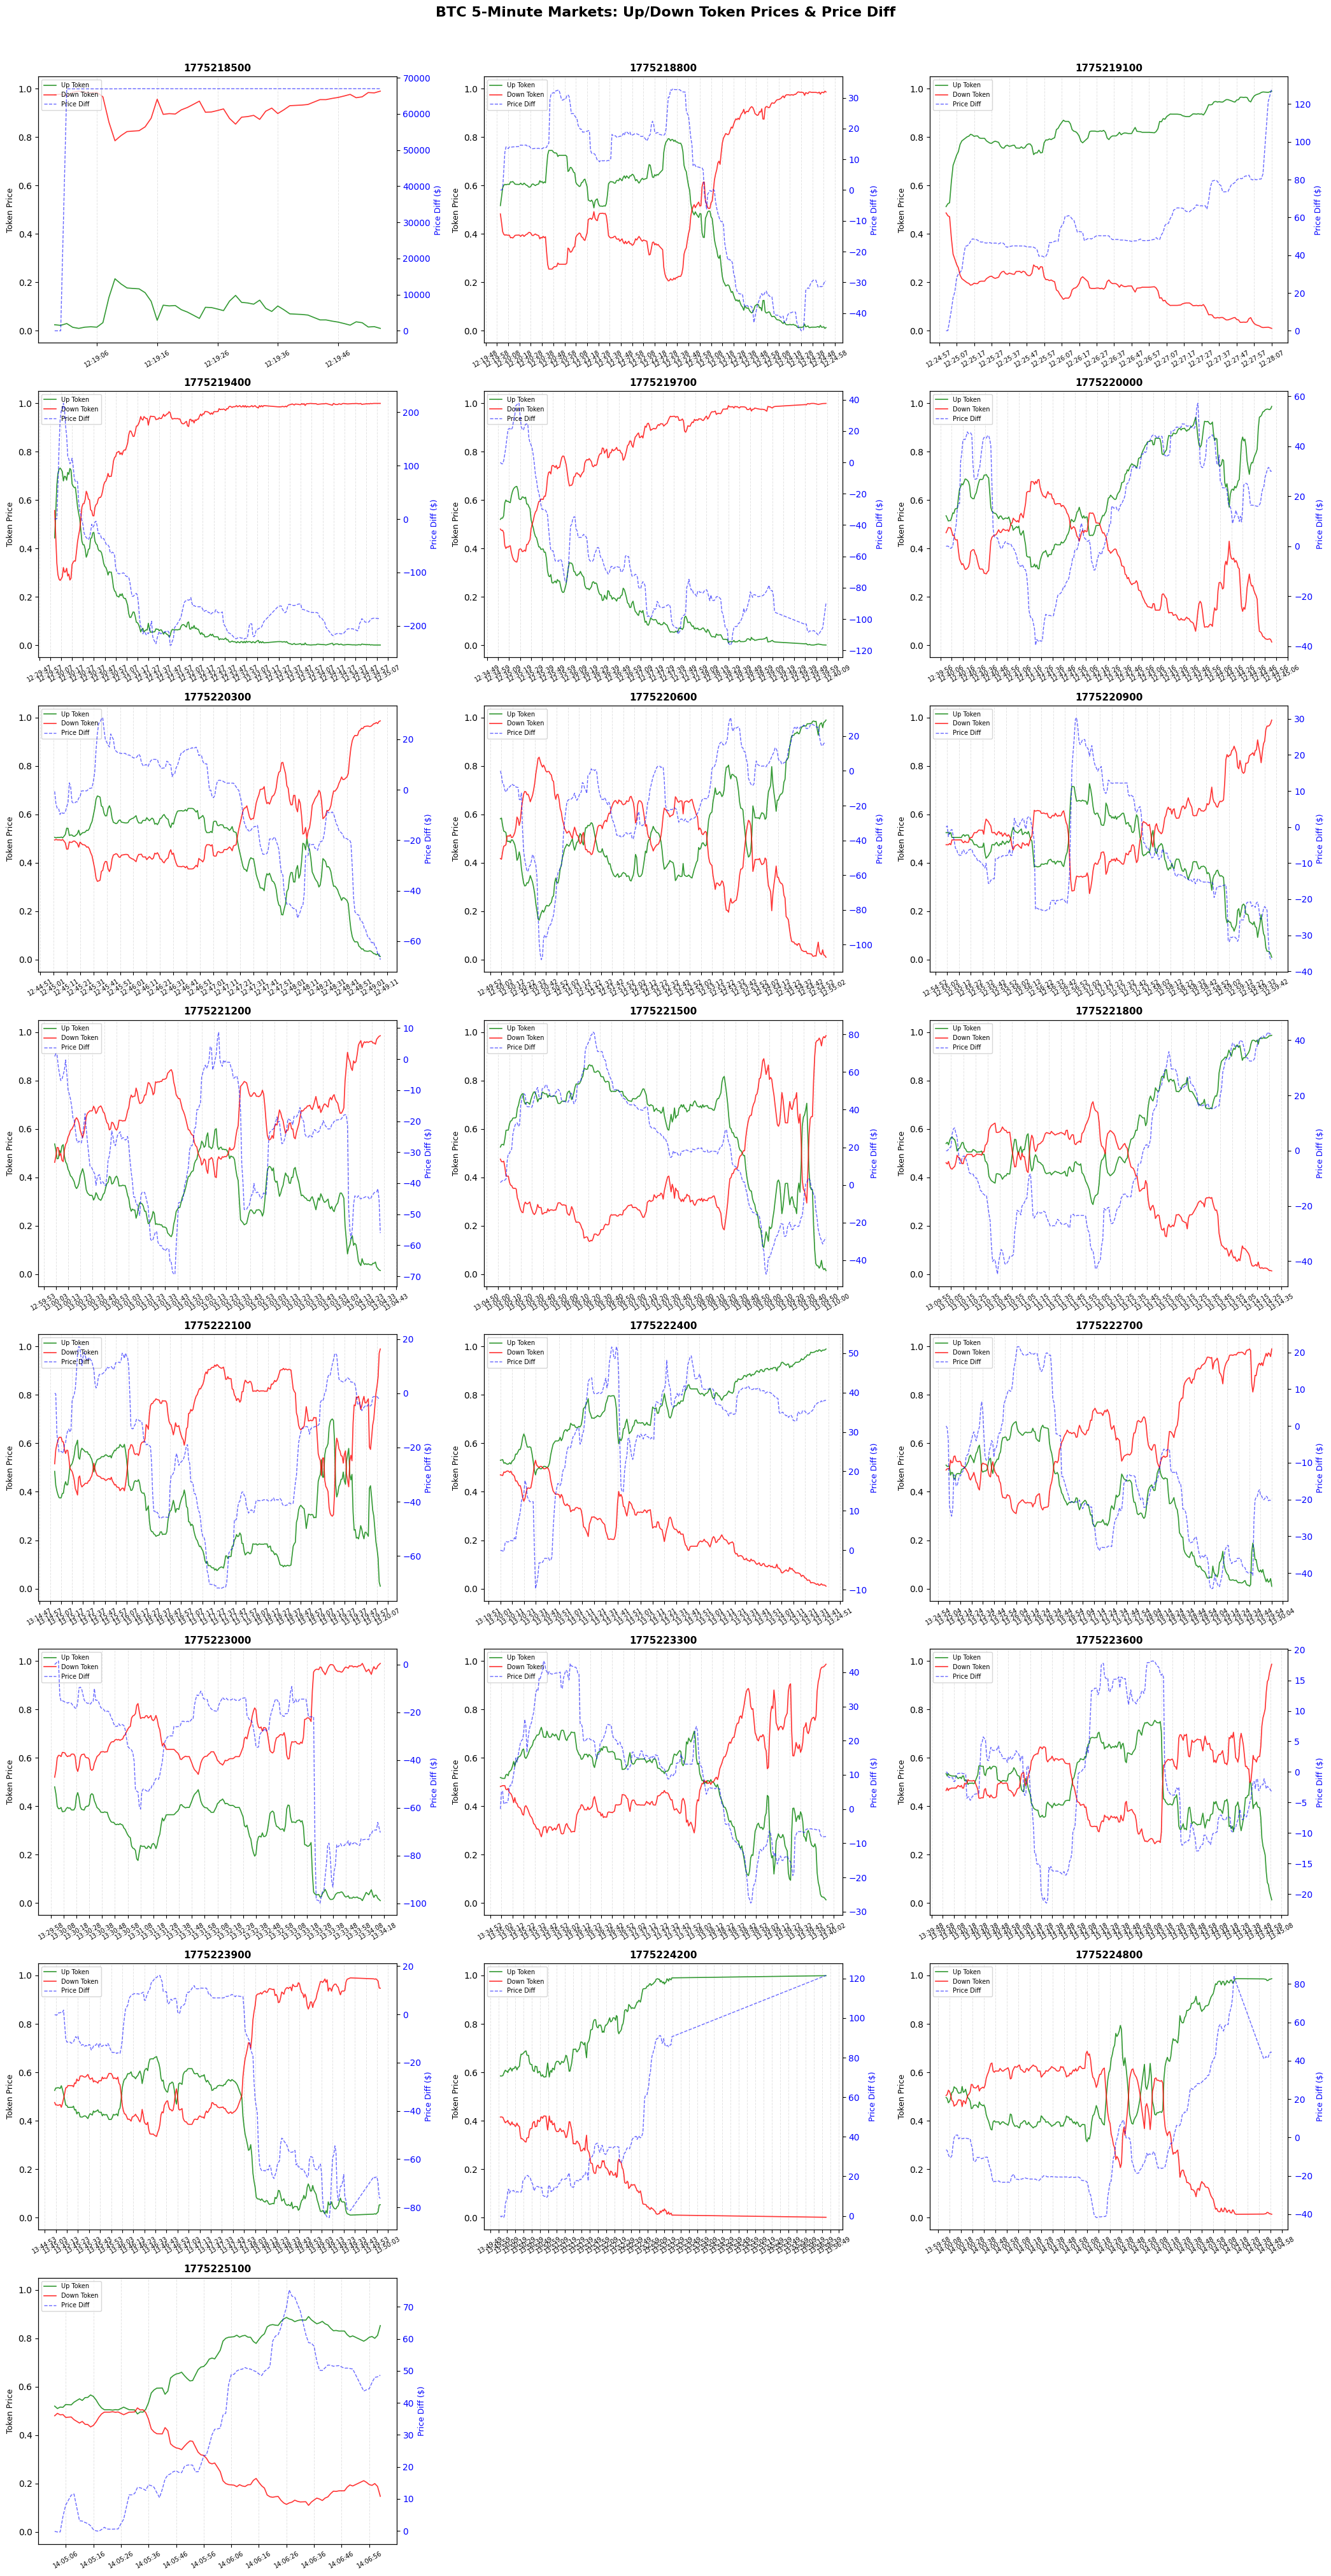

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

windows = sorted(df['window_start'].unique())
n = len(windows)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
axes = axes.flatten()

for i, ws in enumerate(windows):
    ax1 = axes[i]
    subset = df[df['window_start'] == ws].copy()
    label = subset['window_label'].iloc[0]
    
    # Aggregate duplicate timestamps by taking the mean
    agg = subset.groupby('timestamp').agg(
        up_price=('up_price', 'mean'),
        down_price=('down_price', 'mean'),
        price_diff=('price_diff', 'mean')
    ).reset_index()
    agg['time'] = pd.to_datetime(agg['timestamp'], unit='s')
    
    # Plot up/down token prices on left y-axis
    ax1.plot(agg['time'], agg['up_price'], color='green', alpha=0.8, linewidth=1.2, label='Up Token')
    ax1.plot(agg['time'], agg['down_price'], color='red', alpha=0.8, linewidth=1.2, label='Down Token')
    ax1.set_ylabel('Token Price', fontsize=9)
    ax1.set_ylim(-0.05, 1.05)
    ax1.tick_params(axis='y')
    
    # Plot price_diff on right y-axis
    ax2 = ax1.twinx()
    ax2.plot(agg['time'], agg['price_diff'], color='blue', alpha=0.6, linewidth=1, linestyle='--', label='Price Diff')
    ax2.set_ylabel('Price Diff ($)', fontsize=9, color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    
    ax1.set_title(f'{ws}', fontsize=11, fontweight='bold')
    ax1.xaxis.set_major_locator(mdates.SecondLocator(interval=10))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax1.tick_params(axis='x', rotation=30, labelsize=7)
    ax1.grid(True, axis='x', linestyle='--', alpha=0.35, linewidth=0.7)
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper left')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('BTC 5-Minute Markets: Up/Down Token Prices & Price Diff', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()